In [17]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import pandas as pd

# Ensure the notebook can find the /src directory
root_path = Path.cwd().parent
if str(root_path) not in sys.path:
    sys.path.append(str(root_path))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
from src.data_loader import VesselDataLoader
from src.visualizer import VesselVisualizer
from src.data_processing import DataProcessor
from src.mission_profiler import MissionProfiler

In [19]:
# Path to your raw telemetry
raw_data_file1 = root_path / "data" / "raw" / "Rotherhithe_voy_179.csv"
raw_data_file2 = root_path / "data" / "raw" / "Wembley_voy_236.csv"

# Instantiate
loader1 = VesselDataLoader(raw_data_file1)
loader2 = VesselDataLoader(raw_data_file2)

# Load and clean the data
df1 = loader1.load_and_clean()
df2 = loader2.load_and_clean()

processed_df1 = DataProcessor(df1).extract_features_and_filter(filter_method='raw')
processed_df2 = DataProcessor(df2).extract_features_and_filter(filter_method='raw')

profiler = MissionProfiler(speed_threshold=1.0)
reg1 = profiler.generate_phase_registry(processed_df1, source_file_name="Rotherhithe_179.csv")
reg2 = profiler.generate_phase_registry(processed_df2, source_file_name="Wembley_236.csv")
master_registry = pd.concat([reg1, reg2], ignore_index=True)

In [22]:
plotter = VesselVisualizer(processed_df1) # (Passes structural check, can plot master_registry directly)
interactive_plot = plotter.plot_brick_space(master_registry,
                                            # y_axis_metric='Intensive_L1_Power',
                                            include_loitering=True
                                            )
interactive_plot.show()

In [5]:
vessel_map = plotter.plot_trajectory_folium(status_col='PHASE')
vessel_map

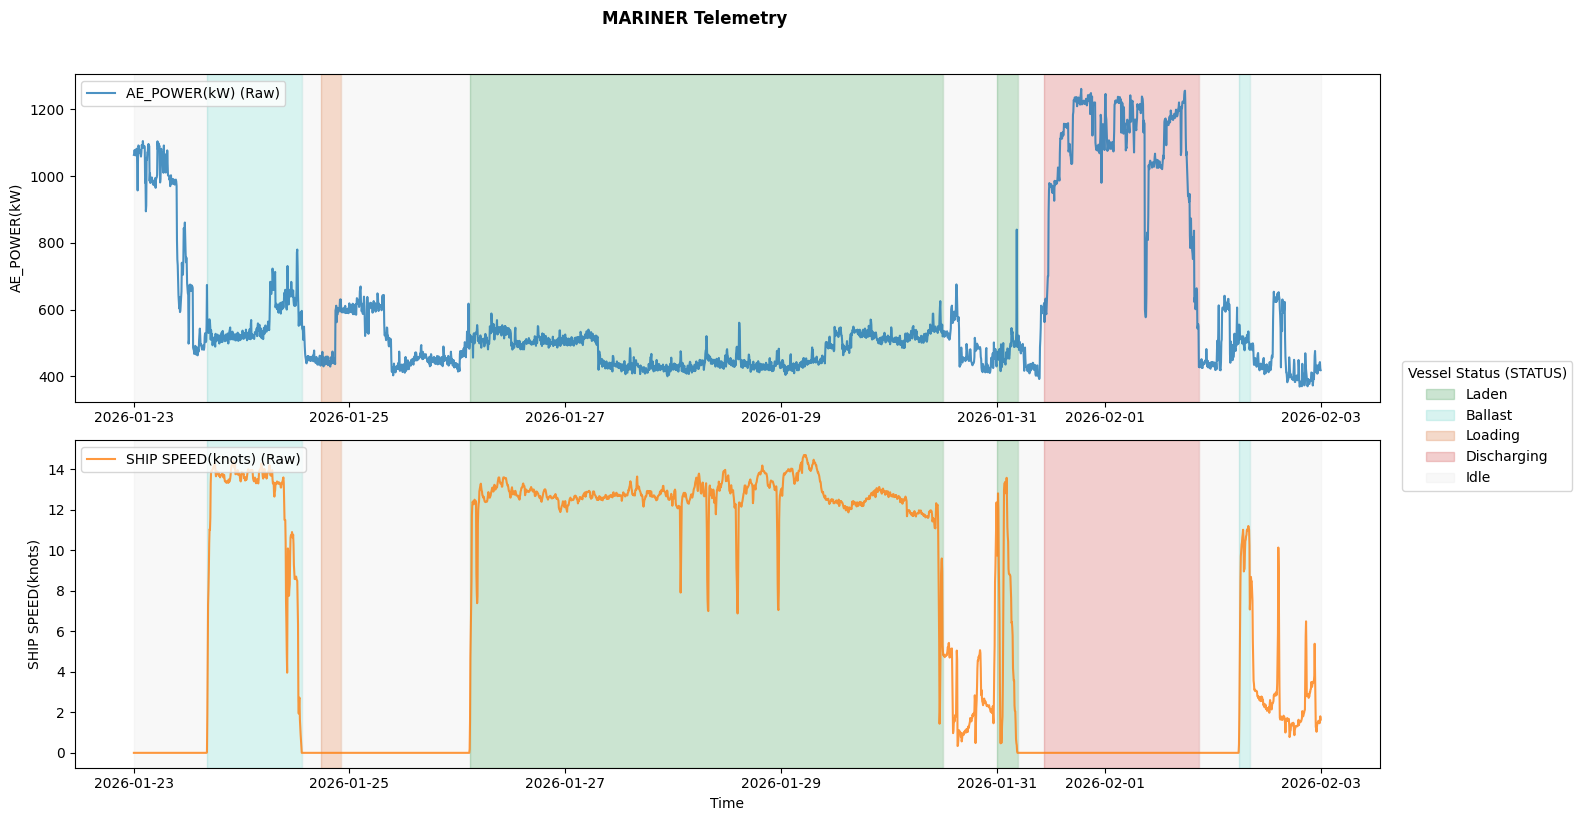

In [6]:
plotter2 = VesselVisualizer(df2)

# Plot using the original STATUS column
fig, ax = plotter2.plot_series(columns=['AE_POWER(kW)', 'SHIP SPEED(knots)'],subplots=True, status_col='STATUS')

In [7]:
vessel_map2 = plotter2.plot_trajectory_folium(status_col='STATUS')
vessel_map2